# Data Preprocessing

### Libraries + loading the data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

In [2]:
# Files
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [3]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Training Set Overview
### Number of rows and columns

In [4]:
train.shape

(8693, 14)

### Column names, non-null count, data type

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


### Class distribution

In [6]:
train['Transported'].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

In [7]:
classdistribution = train['Transported'].value_counts(normalize=True) * 100
print(classdistribution.round(2).astype(str) + "%")

Transported
True     50.36%
False    49.64%
Name: proportion, dtype: object


### Check nulls

In [8]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

## Data Cleaning

### Test set null values

In [9]:
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

### Extracting features from Cabin

In [10]:
# Train
cabin = train['Cabin'].str.split('/', expand=True)
train['Deck'] = cabin[0]
train['CabinNumber'] = pd.to_numeric(cabin[1], errors='coerce')
train['Side'] = cabin[2]

# Test
cabin_test = test['Cabin'].str.split('/', expand=True)
test['Deck'] = cabin_test[0]
test['CabinNumber'] = pd.to_numeric(cabin_test[1], errors='coerce')
test['Side'] = cabin_test[2]

### Drop unnecessary columns

In [11]:
# Removing Cabin (extracted) and unique identifier features
train = train.drop(columns=['Cabin', 'PassengerId', 'Name'])
test  = test.drop(columns=['Cabin', 'PassengerId', 'Name'])

In [12]:
train.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNumber,Side
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S


### Fill blank amenities with 0, and assume all 0s in amenities = CryoSleep

In [16]:
amenities = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# Train
train[amenities] = train[amenities].fillna(0)
zeroamenities = (train[amenities] == 0).all(axis=1)
train['CryoSleep'] = train['CryoSleep'].fillna(zeroamenities.astype(bool))

# Test
test[amenities] = test[amenities].fillna(0)
zeroamenities_test = (test[amenities] == 0).all(axis=1)
test['CryoSleep'] = test['CryoSleep'].fillna(zeroamenities_test.astype(bool))

### Categorical variables - mode imputation

In [17]:
for col in ['HomePlanet', 'Destination', 'Deck', 'Side']:
    modes = train[col].mode()[0]
    train[col] = train[col].fillna(modes)
    test[col] = test[col].fillna(modes)

# VIP - boolean mode imputation
train['VIP'] = train['VIP'].fillna(train['VIP'].mode()[0]).astype(bool)
test['VIP'] = test['VIP'].fillna(train['VIP'].mode()[0]).astype(bool)

### Checking distribution to determine imputation method for numerical variables (with nulls)

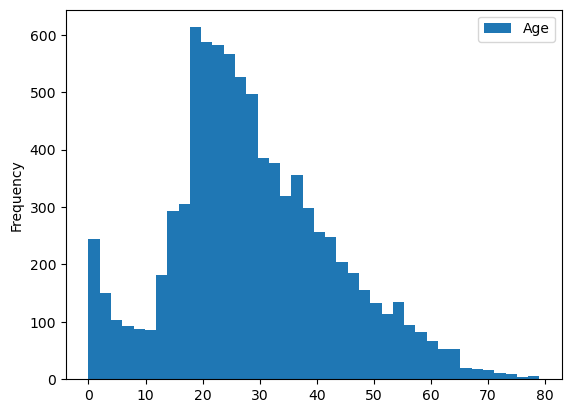

In [18]:
train[['Age']].plot(kind='hist', bins=40)
plt.show()

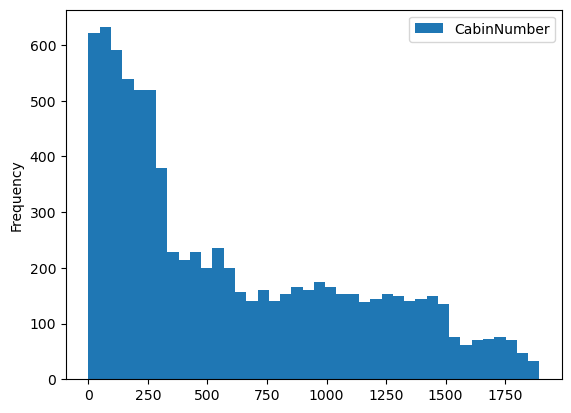

In [19]:
train[['CabinNumber']].plot(kind='hist', bins=40)
plt.show()

Both 'Age' and 'CabinNumber' are right-skewed, so median imputation is appropriate to address null values.

### Numerical variables - median imputation

In [20]:
# Age
train['Age'] = train['Age'].fillna(train['Age'].median())
test['Age'] = test['Age'].fillna(train['Age'].median())

# Cabin number
train['CabinNumber'] = train['CabinNumber'].fillna(train['CabinNumber'].median())
test['CabinNumber'] = test['CabinNumber'].fillna(train['CabinNumber'].median())

In [21]:
# Check nulls
train.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Deck            0
CabinNumber     0
Side            0
dtype: int64

In [22]:
test.isnull().sum()

HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Deck            0
CabinNumber     0
Side            0
dtype: int64

### One-hot encoding

In [23]:
# Boolean encoding
train['CryoSleep'] = train['CryoSleep'].astype(int)
train['VIP'] = train['VIP'].astype(int)

test['CryoSleep'] = test['CryoSleep'].astype(int)
test['VIP'] = test['VIP'].astype(int)

# Encoding remaining categorical variables
categoricals = ['HomePlanet', 'Destination', 'Deck', 'Side']

train = pd.get_dummies(train, columns=categoricals)
test = pd.get_dummies(test, columns=categoricals)

train, test = train.align(test, join='left', axis=1)

In [24]:
train.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,CabinNumber,...,Deck_A,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_P,Side_S
0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,False,0.0,...,False,True,False,False,False,False,False,False,True,False
1,0,24.0,0,109.0,9.0,25.0,549.0,44.0,True,0.0,...,False,False,False,False,False,True,False,False,False,True
2,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,False,0.0,...,True,False,False,False,False,False,False,False,False,True
3,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,False,0.0,...,True,False,False,False,False,False,False,False,False,True
4,0,16.0,0,303.0,70.0,151.0,565.0,2.0,True,1.0,...,False,False,False,False,False,True,False,False,False,True


## Modelling Preparation

In [51]:
X = train.drop(columns=['Transported'])
y = train['Transported'].astype(int)
X_test = X_test = test.drop(columns=['Transported'])

In [52]:
# Standardizing numeric columns for modelling
numeric = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNumber']

standardize = StandardScaler()
X[numeric] = standardize.fit_transform(X[numeric])
X_test[numeric] = standardize.transform(X_test[numeric])

### Feature Importance with Decision Tree

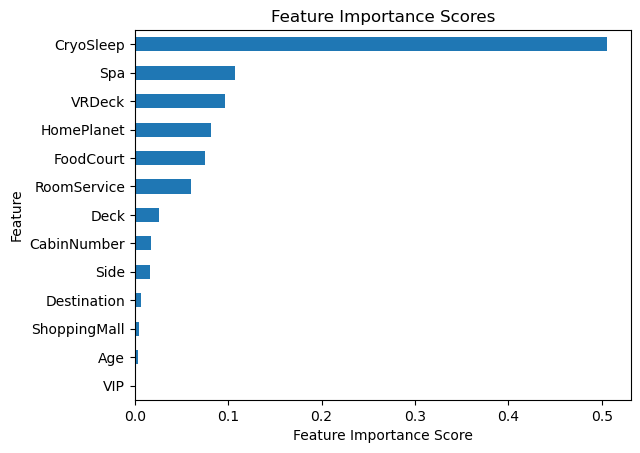

In [50]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

decisiontree = DecisionTreeClassifier(max_depth=5, random_state=42)
decisiontree.fit(X, y)

originals = pd.Series(X.columns.str.split('_').str[0], index=X.columns)

featureimportance = pd.Series(dt.feature_importances_, index=X.columns)
groupedbyoriginal = featureimportance.groupby(originals).sum().sort_values(ascending=False)

groupedbyoriginal.sort_values().plot(kind='barh')
plt.title("Feature Importance Scores")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()

### Feature Selection

### Cleaned & Standardized Data 

In [ ]:
X.to_csv('X.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y.to_csv('y.csv', index=False)